In [2]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go

# Dataset: CO2 Emissions by Country 2000-2022
# Source: Our World in Data (https://ourworldindata.org/co2-emissions)
df = pd.read_csv(r"C:\Users\ADITHYA A M\Downloads\data-viz-class-material-master\data-viz-class-material-master\data\co2_emissions.csv")
print(f"Loaded: {len(df)} rows | Countries: {df['Country'].nunique()} | Years: {df['Year'].min()}-{df['Year'].max()}")
print(df.head())


Loaded: 345 rows | Countries: 15 | Years: 2000-2022
         Country         Region  Year  CO2_Mt  CO2_per_capita
0  United States  North America  2000  5857.6            1.32
1  United States  North America  2001  5724.0            1.26
2  United States  North America  2002  5652.8            1.11
3  United States  North America  2003  5592.8            1.29
4  United States  North America  2004  5743.2            1.12


In [3]:
# Explore before building

print("Countries:", df['Country'].unique())
print("\nCO2 range:", df['CO2_Mt'].min(), "to", df['CO2_Mt'].max(), "Mt")
print("\nRegional averages (2022):")
print(df[df['Year']==2022].groupby('Region')['CO2_Mt'].mean().sort_values(ascending=False).round(1))


Countries: ['United States' 'China' 'India' 'Germany' 'United Kingdom' 'France'
 'Brazil' 'Japan' 'Canada' 'Australia' 'South Korea' 'Russia'
 'South Africa' 'Mexico' 'Indonesia']

CO2 range: 125.3 to 12409.5 Mt

Regional averages (2022):
Region
Asia             3531.1
North America    2393.8
Latin America     629.2
Africa            534.4
Europe            496.5
Oceania           493.7
Name: CO2_Mt, dtype: float64


In [4]:
asia_df = df[df["Region"] == "Asia"]


In [7]:
highlight_country = "India" 

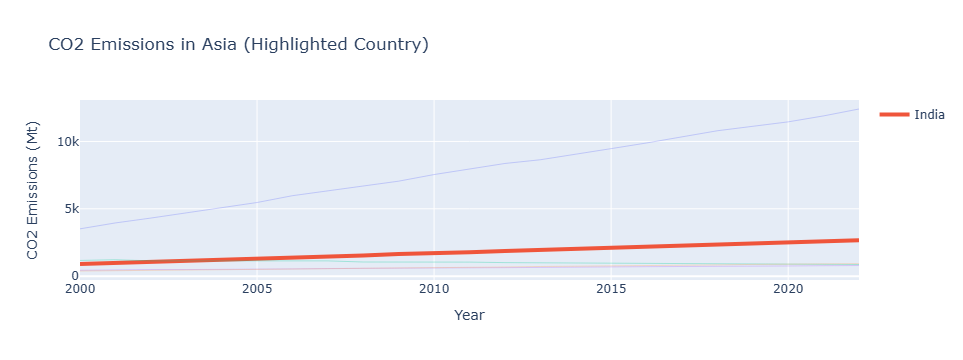

In [8]:
fig = go.Figure()

for country in asia_df["Country"].unique():
    country_df = asia_df[asia_df["Country"] == country]
    
    if country == highlight_country:
        fig.add_trace(go.Scatter(
            x=country_df["Year"],
            y=country_df["CO2_Mt"],
            mode="lines",
            name=country,
            line=dict(width=4)  
        ))
    else:
        fig.add_trace(go.Scatter(
            x=country_df["Year"],
            y=country_df["CO2_Mt"],
            mode="lines",
            name=country,
            line=dict(width=1),
            opacity=0.3,
            showlegend=False
        ))

fig.update_layout(
    title="CO2 Emissions in Asia (Highlighted Country)",
    xaxis_title="Year",
    yaxis_title="CO2 Emissions (Mt)"
)

fig.show()

In [10]:
df_filtered = df[df["Year"].isin([2000, 2022])]

In [11]:
regional_avg = df_filtered.groupby(["Region", "Year"])["CO2_Mt"].mean().reset_index()

In [12]:
pivot_df = regional_avg.pivot(index="Region", columns="Year", values="CO2_Mt").reset_index()

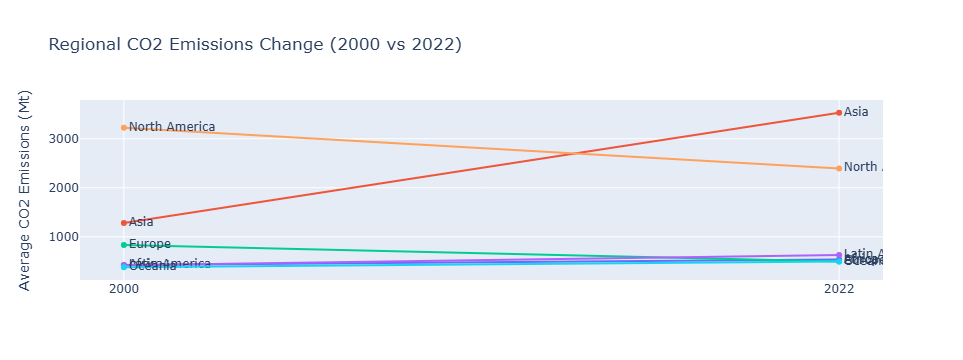

In [13]:
fig = go.Figure()

for _, row in pivot_df.iterrows():
    fig.add_trace(go.Scatter(
        x=[2000, 2022],
        y=[row[2000], row[2022]],
        mode="lines+markers+text",
        text=[row["Region"], row["Region"]],
        textposition="middle right",
        name=row["Region"]
    ))

fig.update_layout(
    title="Regional CO2 Emissions Change (2000 vs 2022)",
    xaxis=dict(
        tickvals=[2000, 2022]
    ),
    yaxis_title="Average CO2 Emissions (Mt)",
    showlegend=False
)

fig.show()